In [1]:
import polars as pl
import pandas as pd
import numpy as np
import catboost
import os
from datetime import date, timedelta
import re
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
test_start_date = date(2024, 8, 1)
val_start_date = date(2024, 7, 1)
val_end_date = date(2024, 7, 31)
train_end_date = date(2024, 6, 30)
data_path = './predict-user-fresh-order/'

# Read data

In [3]:
actions_history = pl.scan_parquet(os.path.join(data_path, 'actions_history')).join(pl.scan_csv(os.path.join(data_path, 'action_type_info.csv')), on='action_type_id').drop('action_type_id').with_columns(
    pl.col('action_type').cast(pl.Categorical).alias('action_type')
)
search_history = pl.scan_parquet(os.path.join(data_path, 'search_history'))
product_information = pl.scan_csv(os.path.join(data_path, 'product_information.csv'))

In [4]:
val_start_date, val_end_date

(datetime.date(2024, 7, 1), datetime.date(2024, 7, 31))

In [5]:
val_target = (
    actions_history
    .filter(pl.col('timestamp').dt.date() >= val_start_date)
    .filter(pl.col('timestamp').dt.date() <= val_end_date)
    .select('user_id', (pl.col('action_type') == 'order').alias('has_order'))
    .group_by('user_id')
    .agg(pl.max('has_order').cast(pl.Int32).alias('target'))
)

In [6]:
val_target.group_by('target').agg(pl.count('user_id')).collect()

target,user_id
i32,u32
0,1227381
1,647575


In [18]:
val_target.group_by('target').agg(pl.count('user_id')).collect_schema()

Schema([('target', Int32), ('user_id', UInt32)])

# Simple pipeline

## Intent features

In [8]:
intent_df = actions_history.with_columns([
    pl.col("timestamp").cast(pl.Datetime),
    ]).sort(["user_id", "timestamp"])

intent_df_7d = intent_df.filter(pl.col("timestamp") >= train_end_date - timedelta(days=7))
intent_df_30d = intent_df.filter(pl.col("timestamp") >= train_end_date - timedelta(days=30))

In [9]:
agg_7d = intent_df_7d.group_by("user_id").agg([
    (pl.col("action_type") == "to_cart").sum().alias("add_to_cart_count_7d"),
    (pl.col("action_type") == "click").sum().alias("product_clicks_7d"),
])

agg_30d = intent_df_30d.group_by("user_id").agg([
    (pl.col("action_type") == "to_cart").sum().alias("add_to_cart_count_30d"),
    (pl.col("action_type") == "view").sum().alias("view_count_30d"),
    (pl.col("action_type") == "search").sum().alias("search_count_30d"),
    (pl.col("action_type") == "click").sum().alias("click_count_30d"),
])

In [14]:
ratios = agg_30d.with_columns([
    ((pl.col("add_to_cart_count_30d") + 1) / (pl.col("click_count_30d") + 1))
    .fill_nan(0)
    .fill_null(0)
    .alias("cart_to_click_ratio"),
]).select(('user_id', 'cart_to_click_ratio'))

## Session features

In [11]:
df_sessions = (
    intent_df
    .with_columns([
        pl.col("timestamp").diff().over("user_id").dt.total_seconds().alias("time_diff_sec"),
    ])
    .with_columns([
        (
            (pl.col("time_diff_sec") > timedelta(minutes=40))
            .fill_null(True)
            .cast(pl.Int8)
        ).alias("new_session_flag")
    ])
    .with_columns([
        pl.col("new_session_flag").cum_sum().over("user_id").alias("session_id")
    ])
)

session_stats = df_sessions.group_by(["user_id", "session_id"]).agg([
    pl.len().alias("session_len")
])

session_agg = session_stats.group_by("user_id").agg([
    pl.col("session_len").mean().alias("avg_actions_per_session"),
    pl.col("session_len").max().alias("max_actions_per_session"),
])

In [12]:
last_actions = (
    intent_df
    .group_by("user_id")
    .agg([
        pl.col("action_type").tail(3).alias("last_3_actions")
    ])
    .with_columns([
        pl.col("last_3_actions").list.len().alias("last_actions_count"),

        pl.col("last_3_actions").list.get(-1, null_on_oob=True).fill_null("NONE").alias("last_action"),
        pl.col("last_3_actions").list.get(-2, null_on_oob=True).fill_null("NONE").alias("last_2_action"),
        pl.col("last_3_actions").list.get(-3, null_on_oob=True).fill_null("NONE").alias("last_3_action"),
    ])
    .with_columns([
        pl.concat_str(
            [
                pl.col("last_3_action"),
                pl.col("last_2_action"),
                pl.col("last_action"),
            ],
            separator="__"
        ).alias("last_3_actions_str")
    ])
).drop('last_3_actions')

In [19]:
actions_feats = (
    val_target
    .join(agg_7d, on='user_id', how='left')
    .join(agg_30d, on='user_id', how='left')
    .join(ratios, on='user_id', how='left')
    .join(session_stats, on='user_id', how='left')
    .join(session_agg, on='user_id', how='left')
    .join(last_actions, on='user_id', how='left')
    .collect(engine="streaming")
)

In [20]:
actions_feats

user_id,target,add_to_cart_count_7d,product_clicks_7d,add_to_cart_count_30d,view_count_30d,search_count_30d,click_count_30d,cart_to_click_ratio,session_id,session_len,avg_actions_per_session,max_actions_per_session,last_actions_count,last_action,last_2_action,last_3_action,last_3_actions_str
i32,i32,u32,u32,u32,u32,u32,u32,f64,i64,u32,f64,u32,u32,cat,cat,cat,str
1924054,0,0,1,0,0,0,1,0.5,1,26,26.0,26,3,"""click""","""click""","""click""","""click__click__click"""
1924208,0,4,12,9,0,0,31,0.3125,1,64,64.0,64,3,"""to_cart""","""click""","""click""","""click__click__to_cart"""
1924241,1,0,0,0,0,0,0,1.0,1,13,13.0,13,3,"""order""","""order""","""favorite""","""favorite__order__order"""
1924269,1,23,50,37,0,0,63,0.59375,1,122,122.0,122,3,"""click""","""click""","""order""","""order__click__click"""
1924397,0,4,1,4,0,0,1,2.5,1,17,17.0,17,3,"""click""","""to_cart""","""to_cart""","""to_cart__to_cart__click"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11183595,0,0,3,0,0,0,3,0.25,1,3,3.0,3,3,"""click""","""click""","""click""","""click__click__click"""
11183596,0,15,1,15,0,0,1,8.0,1,25,25.0,25,3,"""to_cart""","""to_cart""","""to_cart""","""to_cart__to_cart__to_cart"""
11183759,1,4,6,4,0,0,6,0.714286,1,26,26.0,26,3,"""order""","""order""","""order""","""order__order__order"""


## Search

In [13]:
N_SVD_COMPONENTS = 16
MIN_DF = 5
MAX_DF = 0.8
MAX_FEATURES = 5000

In [14]:
PRODUCT_KEYWORDS = [
    "молоко",
    "сыр",
    "творог",
    "йогурт",
    "кефир",
    "батон",
    "хлеб",
    "яйца",
    "курица",
    "банан",
    "яблок",
    "кофе",
    "чай",
    "шоколад",
    "вода",
    "колбас",
]


In [15]:
def normalize_query_expr(col_name: str = "search_query") -> pl.Expr:
    """
    Нормализация текста запроса средствами Polars.
    """
    return (
        pl.col(col_name)
        .cast(pl.String)
        .str.to_lowercase()
        .str.replace_all(r"ё", "е")
        .str.replace_all(r"[^a-zа-я0-9\s]+", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
    )

In [16]:
def build_keyword_flag_exprs(
    query_col: str,
    prefixes: list[str],
    prefix_name: str,
) -> list[pl.Expr]:
    """
    Строит булевы признаки по наличию подстрок/префиксов в запросе.
    """
    exprs = []
    for kw in prefixes:
        safe = re.sub(r"[^a-zA-Zа-яА-Я0-9]+", "_", kw.lower()).strip("_")
        exprs.append(
            pl.col(query_col)
            .str.contains(re.escape(kw), literal=False)
            .fill_null(False)
            .cast(pl.Int8)
            .alias(f"{prefix_name}_{safe}_flag")
        )
    return exprs


In [17]:
search_df = (
    search_history
    .with_columns([
        pl.col("timestamp").cast(pl.Datetime),
        normalize_query_expr("search_query").alias("search_query_norm"),
    ])
    .filter(pl.col("timestamp").dt.date() <= train_end_date)
    .sort(["user_id", "timestamp"])
)

In [18]:
search_7d = search_df.filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=7))
search_30d = search_df.filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30))

In [19]:
query_level = (
    search_df
    .with_columns([
        pl.col("search_query_norm").str.len_chars().alias("query_len_chars"),
        pl.col("search_query_norm").str.split(" ").list.len().alias("query_len_words"),
    ] + build_keyword_flag_exprs("search_query_norm", PRODUCT_KEYWORDS, "product"))
)

In [20]:
query_level_30d = query_level.filter(pl.col("timestamp").dt.date() >= train_end_date - timedelta(days=30) )
query_level_7d = query_level.filter(pl.col("timestamp").dt.date() >= train_end_date - timedelta(days=7))

In [21]:
basic_30d = query_level_30d.group_by("user_id").agg([
    pl.len().alias("search_count_30d"),
    pl.col("search_query_norm").n_unique().alias("unique_queries_30d"),
    pl.col("query_len_chars").mean().alias("avg_query_len_chars_30d"),
    pl.col("query_len_chars").median().alias("median_query_len_chars_30d"),
    pl.col("query_len_words").mean().alias("avg_query_len_words_30d"),
    pl.col("query_len_words").max().alias("max_query_len_words_30d"),
])

basic_7d = query_level_7d.group_by("user_id").agg([
    pl.len().alias("search_count_7d"),
    pl.col("search_query_norm").n_unique().alias("unique_queries_7d"),
])

In [22]:
recency = search_df.group_by("user_id").agg([
    (train_end_date - pl.col("timestamp").max().dt.date()).dt.total_days()
    .alias("days_since_last_search")
])

### Text features

In [23]:
product_flag_cols = [f"product_{re.sub(r'[^a-zA-Zа-яА-Я0-9]+', '_', kw.lower()).strip('_')}_flag"
                     for kw in PRODUCT_KEYWORDS]

keyword_aggs = []

In [24]:
for col in product_flag_cols:
    keyword_aggs.extend([
        pl.col(col).sum().alias(f"{col}_count_30d"),
        pl.col(col).mean().alias(f"{col}_rate_30d"),
    ])

In [25]:
keyword_features = query_level_30d.group_by("user_id").agg(keyword_aggs)

keyword_summary = query_level_30d.group_by("user_id").agg([
    pl.sum_horizontal(product_flag_cols).sum().alias("product_keyword_hits_30d"),
    (pl.sum_horizontal(product_flag_cols) > 0).sum().alias("queries_with_product_keywords_30d"),
])

In [ ]:
user_docs = (
    search_30d
    .group_by("user_id")
    .agg([
        pl.col("search_query_norm").str.concat(" ").alias("all_queries_text_30d"),
        pl.len().alias("search_count_for_text"),
    ])
).collect(engine="streaming")

/tmp/ipykernel_20258/702763268.py:5: DeprecationWarning: `str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.
  pl.col("search_query_norm").str.concat(" ").alias("all_queries_text_30d"),


In [27]:
user_docs_pd = user_docs.to_pandas()

In [28]:
vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=MIN_DF,
        max_df=MAX_DF,
        max_features=MAX_FEATURES,
        sublinear_tf=True,
    )

X_tfidf = vectorizer.fit_transform(user_docs_pd["all_queries_text_30d"].fillna(""))

In [29]:
svd = TruncatedSVD(n_components=N_SVD_COMPONENTS)
X_svd = svd.fit_transform(X_tfidf)

In [30]:
svd_cols = [f"search_tfidf_svd_{i:02d}" for i in range(X_svd.shape[1])]

tfidf_svd_features = pl.DataFrame({
    "user_id": user_docs_pd["user_id"].tolist(),
    **{col: X_svd[:, i].tolist() for i, col in enumerate(svd_cols)}
})

### Last search actions

In [31]:
last_query_features = (
    query_level
    .group_by("user_id")
    .agg([
        pl.col("search_query_norm").last().alias("last_search_query"),
        pl.col("query_len_chars").last().alias("last_search_len_chars"),
        pl.col("query_len_words").last().alias("last_search_len_words"),
    ])
)

In [32]:
last_query_features = last_query_features.with_columns([
    *[
        pl.col("last_search_query")
        .str.contains(re.escape(kw), literal=False)
        .fill_null(False)
        .cast(pl.Int8)
        .alias(f"last_query_product_{re.sub(r'[^a-zA-Zа-яА-Я0-9]+', '_', kw.lower()).strip('_')}")
        for kw in PRODUCT_KEYWORDS
    ],
])

In [ ]:
search_features = (
    basic_30d
    .join(recency.lazy(), on="user_id", how="full")
    .join(keyword_features.lazy(), on="user_id", how="full")
    .join(keyword_summary.lazy(), on="user_id", how="full")
    .join(tfidf_svd_features.lazy(), on="user_id", how="full")
    .join(last_query_features.lazy(), on="user_id", how="full")
    .join(basic_7d.lazy(), on="user_id", how="full")
).collect(engine="streaming")

In [34]:
search_features

user_id,search_count_30d,unique_queries_30d,avg_query_len_chars_30d,median_query_len_chars_30d,avg_query_len_words_30d,max_query_len_words_30d,days_since_last_search,product_молоко_flag_count_30d,product_молоко_flag_rate_30d,product_сыр_flag_count_30d,product_сыр_flag_rate_30d,product_творог_flag_count_30d,product_творог_flag_rate_30d,product_йогурт_flag_count_30d,product_йогурт_flag_rate_30d,product_кефир_flag_count_30d,product_кефир_flag_rate_30d,product_батон_flag_count_30d,product_батон_flag_rate_30d,product_хлеб_flag_count_30d,product_хлеб_flag_rate_30d,product_яйца_flag_count_30d,product_яйца_flag_rate_30d,product_курица_flag_count_30d,product_курица_flag_rate_30d,product_банан_flag_count_30d,product_банан_flag_rate_30d,product_яблок_flag_count_30d,product_яблок_flag_rate_30d,product_кофе_flag_count_30d,product_кофе_flag_rate_30d,product_чай_flag_count_30d,product_чай_flag_rate_30d,product_шоколад_flag_count_30d,product_шоколад_flag_rate_30d,product_вода_flag_count_30d,…,search_tfidf_svd_00,search_tfidf_svd_01,search_tfidf_svd_02,search_tfidf_svd_03,search_tfidf_svd_04,search_tfidf_svd_05,search_tfidf_svd_06,search_tfidf_svd_07,search_tfidf_svd_08,search_tfidf_svd_09,search_tfidf_svd_10,search_tfidf_svd_11,search_tfidf_svd_12,search_tfidf_svd_13,search_tfidf_svd_14,search_tfidf_svd_15,last_search_query,last_search_len_chars,last_search_len_words,last_query_product_молоко,last_query_product_сыр,last_query_product_творог,last_query_product_йогурт,last_query_product_кефир,last_query_product_батон,last_query_product_хлеб,last_query_product_яйца,last_query_product_курица,last_query_product_банан,last_query_product_яблок,last_query_product_кофе,last_query_product_чай,last_query_product_шоколад,last_query_product_вода,last_query_product_колбас,search_count_7d,unique_queries_7d
i32,u32,u32,f64,f64,f64,u32,i64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,u32,u32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,u32,u32
5753971,3,2,22.666667,22.0,3.333333,4,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,…,0.069114,0.044232,0.005503,-0.028134,0.00537,0.003719,0.003429,-0.008934,-0.000559,-0.011854,-0.000258,-0.001126,-0.015469,-0.001768,-0.003698,-0.015131,"""блендер стакан kitfort""",22,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2
6010460,3,3,15.666667,17.0,2.666667,3,27,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,…,0.001841,-0.000076,-0.00019,-0.001013,0.000121,0.000457,0.000231,0.001223,0.005738,0.000515,-0.002956,-0.003595,0.000898,0.000902,0.001168,-0.000609,"""samsung 128gb""",13,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,null
6859628,3,3,9.0,9.0,1.333333,2,6,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,…,0.033209,-0.087498,0.228051,-0.021663,0.042791,-0.027378,-0.000335,0.007529,-0.004688,0.004977,0.001051,-0.006788,-0.001143,0.000035,0.005626,0.000019,"""бокс сладостей""",14,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,3
7714249,66,61,11.590909,9.5,1.80303,6,0,1,0.015152,5,0.075758,0,0.0,1,0.015152,0,0.0,0,0.0,0,0.0,0,0.0,1,0.015152,0,0.0,0,0.0,1,0.015152,0,0.0,1,0.015152,0,…,0.174504,-0.147342,-0.052486,-0.009845,-0.102035,-0.028947,-0.013261,-0.059485,0.008095,-0.05439,0.02089,-0.008521,-0.013915,0.021506,-0.095801,-0.003327,"""пицца""",5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,9
7721894,2,2,7.5,7.5,1.5,2,28,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,…,0.039006,-0.064745,0.008763,0.002123,-0.01927,0.012974,-0.006836,-0.019838,0.017863,-0.028398,-0.001185,0.032963,0.007131,0.012447,-0.074125,-0.032015,"""чипсы lays""",10,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2541437,3,3,16.333333,13.0,3.333333

## Price features

In [22]:
TOP_K_CATEGORIES = 10

PRODUCT_ACTIONS = ["view", "click", "to_cart", "favorite", "order"]

PRICE_ACTIONS = ["view", "click", "to_cart", "order"]

In [26]:
actions_df = (    
    actions_history
    .filter(pl.col("timestamp").dt.date() <= train_end_date)
    .filter(pl.col("timestamp").dt.date() >= train_end_date - timedelta(days = 30 * 4))
    .filter(pl.col("product_id").is_not_null())
)

products_df = (
    product_information
    .with_columns([
        pl.col("price").cast(pl.Float64),
        pl.col("discount_price").cast(pl.Float64),
        pl.col("category_id").cast(pl.Int64),
        pl.col("category_name").cast(pl.String),
        pl.col("brand").cast(pl.String),
        pl.col("type").cast(pl.String),
    ])
    .select([
        "product_id",
        "brand",
        "type",
        "category_id",
        "category_name",
        "price",
        "discount_price",
    ])
)

In [27]:
events = (
    actions_df
    .join(products_df, on="product_id", how="left")
    .with_columns([
        pl.when(
            pl.col("discount_price").is_not_null() &
            (pl.col("discount_price") > 0)
        )
        .then(pl.col("discount_price"))
        .otherwise(pl.col("price"))
        .alias("effective_price"),

        pl.when(
            pl.col("price").is_not_null() &
            (pl.col("price") > 0) &
            pl.col("discount_price").is_not_null() &
            (pl.col("discount_price") >= 0) &
            (pl.col("discount_price") <= pl.col("price"))
        )
        .then((pl.col("price") - pl.col("discount_price")) / pl.col("price"))
        .otherwise(0.0)
        .alias("discount_ratio"),

        pl.when(
            pl.col("price").is_not_null() &
            pl.col("discount_price").is_not_null() &
            (pl.col("price") > pl.col("discount_price"))
        )
        .then(1)
        .otherwise(0)
        .cast(pl.Int8)
        .alias("is_discounted")
    ])
)

In [28]:
product_events = events.filter(pl.col("action_type").is_in(PRODUCT_ACTIONS))
price_events = events.filter(pl.col("action_type").is_in(PRICE_ACTIONS))

In [42]:
price_features = (
    price_events
    .group_by("user_id")
    .agg([
        pl.col("effective_price").mean().alias("avg_viewed_price"),
        pl.col("effective_price").median().alias("median_viewed_price"),
        pl.col("effective_price").max().alias("max_viewed_price"),
        pl.col("discount_ratio").mean().alias("discount_ratio_mean"),
        pl.col("is_discounted").mean().alias("fraction_discounted_products"),
    ])
).collect(engine="streaming")

In [44]:
price_features

user_id,avg_viewed_price,median_viewed_price,max_viewed_price,discount_ratio_mean,fraction_discounted_products
i32,f64,f64,f64,f64,f64
3193655,96.4375,79.0,199.0,0.219612,0.875
8817749,630.0,630.0,1251.0,0.150168,0.5
9599382,531.190476,300.0,2739.0,0.207768,0.619048
6010412,233.666667,250.0,312.0,0.080041,0.333333
4065723,842.0,842.0,1259.0,0.253163,1.0
…,…,…,…,…,…
10420056,1604.102238,868.0,8915.0,0.438793,0.904762
7564222,3534.583333,723.0,32763.0,0.225458,0.638889
10146762,848.0,848.0,848.0,0.565128,1.0


## Category features

In [32]:
user_category_counts = (
    product_events
    .filter(pl.col("category_id").is_not_null())
    .group_by(["user_id", "category_id", "category_name"])
    .agg([
        pl.len().alias("category_event_count")
    ])
)

user_category_totals = (
    user_category_counts
    .group_by("user_id")
    .agg([
        pl.col("category_event_count").sum().alias("total_category_events"),
        pl.col("category_event_count").max().alias("favorite_category_count"),
        pl.len().alias("unique_categories"),
    ])
    .with_columns([
        (
            pl.col("favorite_category_count") /
            pl.col("total_category_events")
        ).alias("favorite_category_share")
    ])
)

In [33]:
category_entropy = (
    user_category_counts
    .join(
        user_category_totals.select(["user_id", "total_category_events"]),
        on="user_id",
        how="left"
    )
    .with_columns([
        (pl.col("category_event_count") / pl.col("total_category_events")).alias("p_cat")
    ])
    .with_columns([
        pl.when(pl.col("p_cat") > 0)
        .then(-pl.col("p_cat") * pl.col("p_cat").log())
        .otherwise(0.0)
        .alias("entropy_term")
    ])
    .group_by("user_id")
    .agg([
        pl.col("entropy_term").sum().alias("category_entropy")
    ])
)

In [37]:
top_categories = (
    product_events
    .filter(pl.col("category_id").is_not_null())
    .group_by(["category_id", "category_name"])
    .agg(pl.len().alias("global_category_count"))
    .sort("global_category_count", descending=True)
    .head(TOP_K_CATEGORIES)
).collect(engine="streaming")

top_category_ids = top_categories["category_id"].to_list()

In [ ]:
user_category_totals.collect().head()

In [39]:
user_top_category_features = (
    product_events
    .filter(pl.col("category_id").is_in(top_category_ids))
    .group_by(["user_id", "category_id"])
    .agg(pl.len().alias("cnt"))
    .join(
        user_category_totals.select(["user_id", "total_category_events"]),
        on="user_id",
        how="left"
    )
    .with_columns([
        (pl.col("cnt") / pl.col("total_category_events")).alias("share")
    ])
    .collect(engine="streaming")
    .pivot(
        values="share",
        index="user_id",
        on="category_id",
        aggregate_function="first"
    )
    .fill_null(0.0)
)

In [40]:
rename_map = {
    col: f"top_category_share_{col}"
    for col in user_top_category_features.columns
    if col != "user_id"
}
user_top_category_features = user_top_category_features.rename(rename_map)

In [46]:
category_features = (
    user_category_totals
    .join(category_entropy, on="user_id", how="left")
    .join(user_top_category_features.lazy(), on="user_id", how="left")
).collect(engine="streaming")

SchemaError: datatypes of join keys don't match - `user_id`: i32 on left does not match `user_id`: f64 on right (and no other type was available to cast to)

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["user_id", "top_category_share_236", "top_category_share_829", "top_category_share_623", ...]; PROJECT */11 COLUMNS

## Feats

In [14]:
train_end_date, train_end_date - timedelta(days=30 * 4)

(datetime.date(2024, 6, 30), datetime.date(2024, 3, 2))

In [ ]:
actions_aggs = {}
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    5: "to_cart",
}
for id_, suf in actions_id_to_suf.items():
    aggs = (
        actions_history
        .filter(pl.col('timestamp').dt.date() <= train_end_date)
        .filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30 * 4))
        .filter(pl.col('action_type_id') == id_)
        .join(
            product_information
            .select('product_id', 'discount_price'),
            on='product_id',
        )
        .group_by('user_id')
        .agg(
            pl.count('product_id').cast(pl.Int32).alias(f'num_products_{suf}'),
            pl.sum('discount_price').cast(pl.Float32).alias(f'sum_discount_price_{suf}'),
            pl.max('discount_price').cast(pl.Float32).alias(f'max_discount_price_{suf}'),
            pl.max('timestamp').alias(f'last_{suf}_time'),
            pl.min('timestamp').alias(f'first_{suf}_time'),
        )
        .with_columns([
            (pl.lit(val_start_date) - pl.col(f'last_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_last_{suf}'),
            
            (pl.lit(val_start_date) - pl.col(f'first_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_first_{suf}'),
        ])
        .select(
            'user_id',
            f'num_products_{suf}',
            f'sum_discount_price_{suf}',
            f'max_discount_price_{suf}',
            f'days_since_last_{suf}',
            f'days_since_first_{suf}',
        )
    )
    actions_aggs[id_] = aggs

In [12]:
# search_aggs
id_ = 4
suf = 'search'
actions_aggs[id_] = (
    search_history
    .filter(pl.col('action_type_id') == id_)
    .filter(pl.col('timestamp').dt.date() <= train_end_date)
    .filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30 * 4))
    .group_by('user_id')
    .agg(
        pl.count('search_query').cast(pl.Int32).alias(f'num_{suf}'),
        pl.max('timestamp').alias(f'last_{suf}_time'),
        pl.min('timestamp').alias(f'first_{suf}_time'),
    )
    .with_columns([
        (pl.lit(val_start_date) - pl.col(f'last_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_last_{suf}'),

        (pl.lit(val_start_date) - pl.col(f'first_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_first_{suf}'),
    ])
    .select(
        'user_id',
        f'num_{suf}',
        f'days_since_last_{suf}',
        f'days_since_first_{suf}',
    )
)

In [13]:
actions_aggs.keys()

dict_keys([1, 2, 3, 5, 4])

In [14]:
df = val_target
for _, actions_aggs_df in actions_aggs.items():
    df = (
        df
        .join(actions_aggs_df, on='user_id', how='left')
    )

In [15]:
df

user_id,target,num_products_click,sum_discount_price_click,max_discount_price_click,days_since_last_click,days_since_first_click,num_products_favorite,sum_discount_price_favorite,max_discount_price_favorite,days_since_last_favorite,days_since_first_favorite,num_products_order,sum_discount_price_order,max_discount_price_order,days_since_last_order,days_since_first_order,num_products_to_cart,sum_discount_price_to_cart,max_discount_price_to_cart,days_since_last_to_cart,days_since_first_to_cart,num_search,days_since_last_search,days_since_first_search
i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,i32,i32
6954578,0,1,439.0,439.0,39,39,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
7122494,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
10953565,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
10492565,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
8148068,0,71,27132.0,1464.0,28,116,null,null,null,null,null,71,11182.0,1009.0,26,116,84,16904.0,1279.0,1,116,104,0,116
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
7566452,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
7921154,0,null,null,null,null,null,null,null,null,null,null,1,519.0,519.0,33,33,null,null,null,null,null,null,null,null
10976359,0,3,539.0,321.0,109,115,null,null,null,null,null,null,null,null,null,null,13,2734.0,463.0,109,115,9,115,115


In [16]:
df_pd = df.to_pandas()

In [17]:
mask = df_pd.user_id % 10 <= 6

In [18]:
df_pd.columns

Index(['user_id', 'target', 'num_products_click', 'sum_discount_price_click',
       'max_discount_price_click', 'days_since_last_click',
       'days_since_first_click', 'num_products_favorite',
       'sum_discount_price_favorite', 'max_discount_price_favorite',
       'days_since_last_favorite', 'days_since_first_favorite',
       'num_products_order', 'sum_discount_price_order',
       'max_discount_price_order', 'days_since_last_order',
       'days_since_first_order', 'num_products_to_cart',
       'sum_discount_price_to_cart', 'max_discount_price_to_cart',
       'days_since_last_to_cart', 'days_since_first_to_cart', 'num_search',
       'days_since_last_search', 'days_since_first_search'],
      dtype='object')

In [20]:
df_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1874956 entries, 0 to 1874955
Data columns (total 25 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   user_id                      int32  
 1   target                       int32  
 2   num_products_click           float64
 3   sum_discount_price_click     float32
 4   max_discount_price_click     float32
 5   days_since_last_click        float64
 6   days_since_first_click       float64
 7   num_products_favorite        float64
 8   sum_discount_price_favorite  float32
 9   max_discount_price_favorite  float32
 10  days_since_last_favorite     float64
 11  days_since_first_favorite    float64
 12  num_products_order           float64
 13  sum_discount_price_order     float32
 14  max_discount_price_order     float32
 15  days_since_last_order        float64
 16  days_since_first_order       float64
 17  num_products_to_cart         float64
 18  sum_discount_price_to_cart   float32
 19  

## Обработка данных

Сначала посмотрим на данные

In [21]:
from utils import plot_float_feature_histograms
from utils2 import AutoFeatureStandardizer

In [ ]:
X = df_pd.drop(columns=['user_id', 'target'])
y = df_pd.loc[:].target

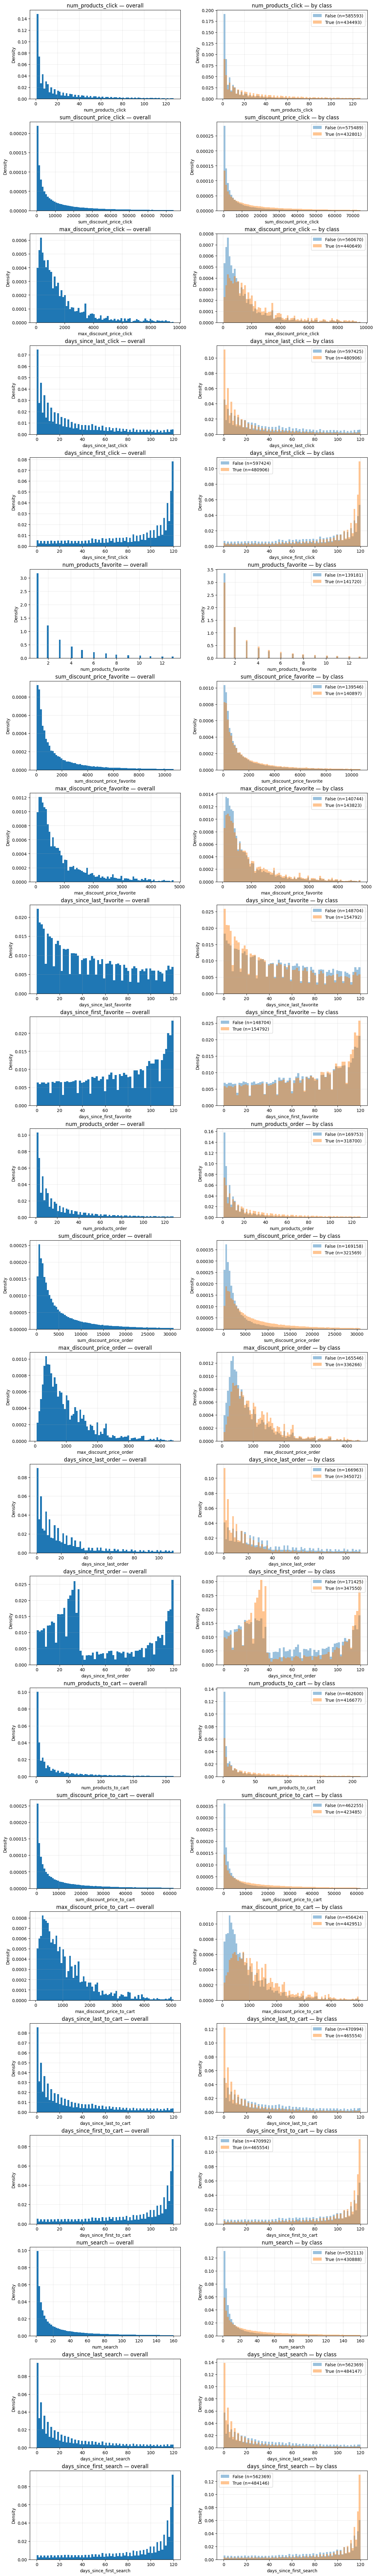

In [23]:
fig, axes = plot_float_feature_histograms(
    dataset=(X, y),
    class_0_label="False",
    class_1_label="True",
)

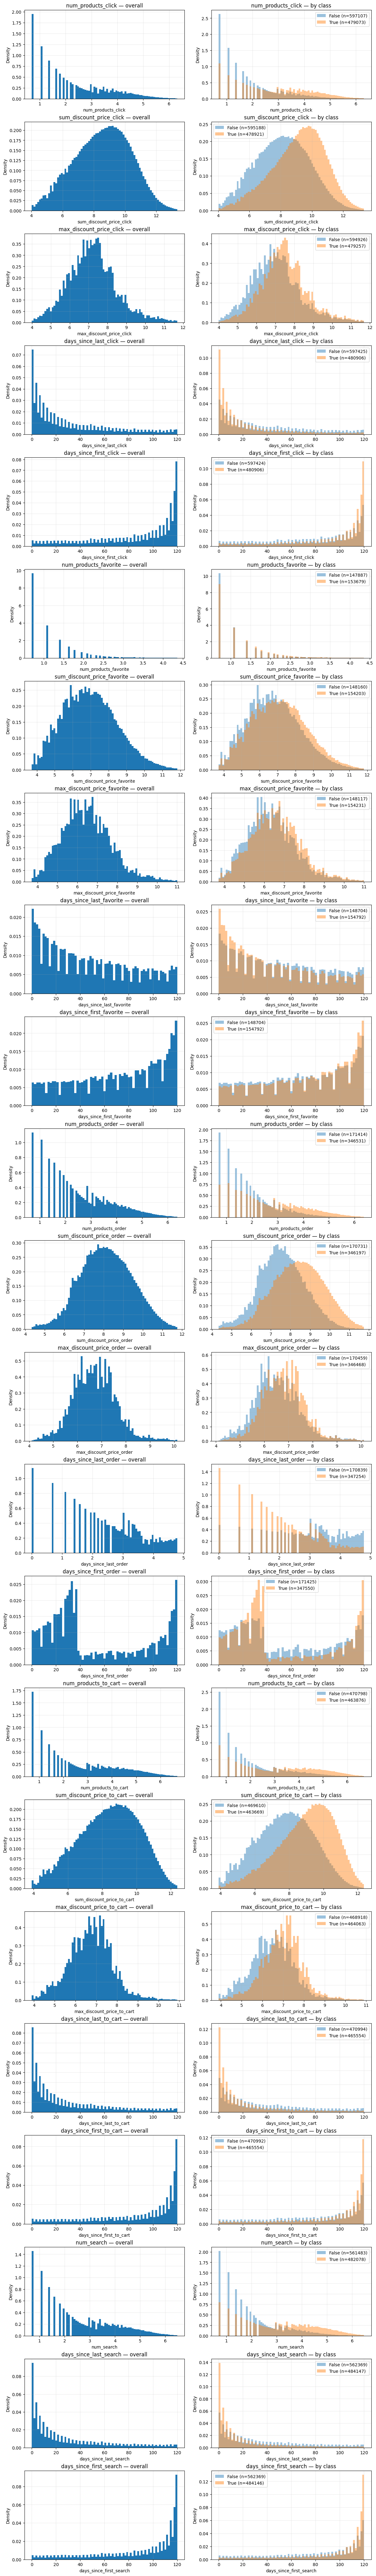

In [24]:
std = AutoFeatureStandardizer(add_indicators=False)

X_transformed = std.fit_transform(X)
fig, axes = plot_float_feature_histograms(
    dataset=(X_transformed, y),
    class_0_label="False",
    class_1_label="True",
)

X = X_transformed

In [25]:
X_train = X.loc[mask, cols]
y_train = y.loc[mask]
X_val = X.loc[~mask, cols]
y_val = y.loc[~mask]

In [26]:
params = {
    'iterations': 2000,
    'depth': 7, 
    'learning_rate': 0.05, 
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': 'GPU',
}

In [27]:
model = catboost.CatBoostClassifier(**params)
model.fit(X_train, y_train, early_stopping_rounds=50, use_best_model=True, eval_set=(X_val, y_val))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7464142	best: 0.7464142 (0)	total: 40.7ms	remaining: 1m 21s
1:	total: 48.9ms	remaining: 48.8s
2:	total: 57.6ms	remaining: 38.3s
3:	total: 66.4ms	remaining: 33.1s
4:	total: 75ms	remaining: 29.9s
5:	test: 0.7528982	best: 0.7528982 (5)	total: 83.8ms	remaining: 27.8s
6:	total: 92.2ms	remaining: 26.3s
7:	total: 101ms	remaining: 25.2s
8:	total: 109ms	remaining: 24.2s
9:	total: 118ms	remaining: 23.6s
10:	test: 0.7533818	best: 0.7533818 (10)	total: 127ms	remaining: 22.9s
11:	total: 135ms	remaining: 22.4s
12:	total: 144ms	remaining: 21.9s
13:	total: 152ms	remaining: 21.6s
14:	total: 160ms	remaining: 21.2s
15:	test: 0.7540496	best: 0.7540496 (15)	total: 170ms	remaining: 21.1s
16:	total: 178ms	remaining: 20.7s
17:	total: 187ms	remaining: 20.6s
18:	total: 195ms	remaining: 20.3s
19:	total: 204ms	remaining: 20.2s
20:	test: 0.7544572	best: 0.7544572 (20)	total: 212ms	remaining: 20s
21:	total: 221ms	remaining: 19.8s
22:	total: 229ms	remaining: 19.7s
23:	total: 238ms	remaining: 19.6s
24:	tot

## Версия 0.1
Ну в изначальном решении на первый бейзлайн какой-то кринж получился, так что начнём издевательство над моделью тут

In [28]:
from utils2 import BinaryClassifierInterpreter
import matplotlib.pyplot as plt

In [29]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train, y_train),
    val=(X_val, y_val),
    model=model,
    enable_early_stopping=True,
    use_best_model=True,
    early_stopping_rounds=100,
)

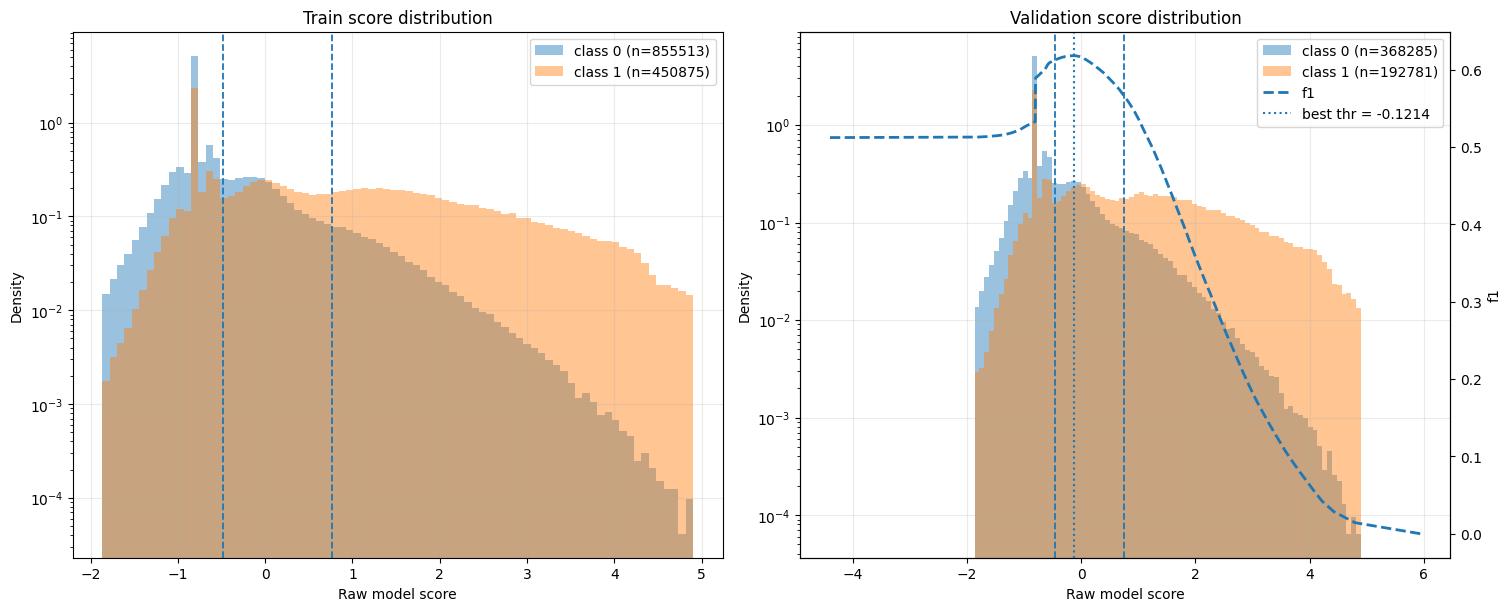

In [30]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

Ну уже видна лажа номер 1 - у нас есть уж очень частый скор и он точно не помогает нам различать два класса (в районе -0.7 если оценивать на глаз). Это надо будет поисследовать. Также можно увидеть, что две гистограммы в целом довольно сильно друг на друга наползают. 

ScoreFeatureContourPlotResult(fitted_model=<catboost.core.CatBoostClassifier object at 0x7fc8a4195010>, fig=<Figure size 1600x700 with 6 Axes>, train_scores=array([-0.80626771, -0.80626771, -0.80626771, ...,  0.63865388,
       -0.80626771, -0.80626771], shape=(1311636,)), val_scores=array([-0.96670193,  1.98842045, -0.80626771, ..., -0.80626771,
       -0.80626771,  0.1199301 ], shape=(563320,)), train_feature_values=array([nan, nan, nan, ..., nan, nan, nan], shape=(1311636,)), val_feature_values=array([ 6.08677473, 10.20850598,         nan, ...,         nan,
               nan,  6.29156914], shape=(563320,)))

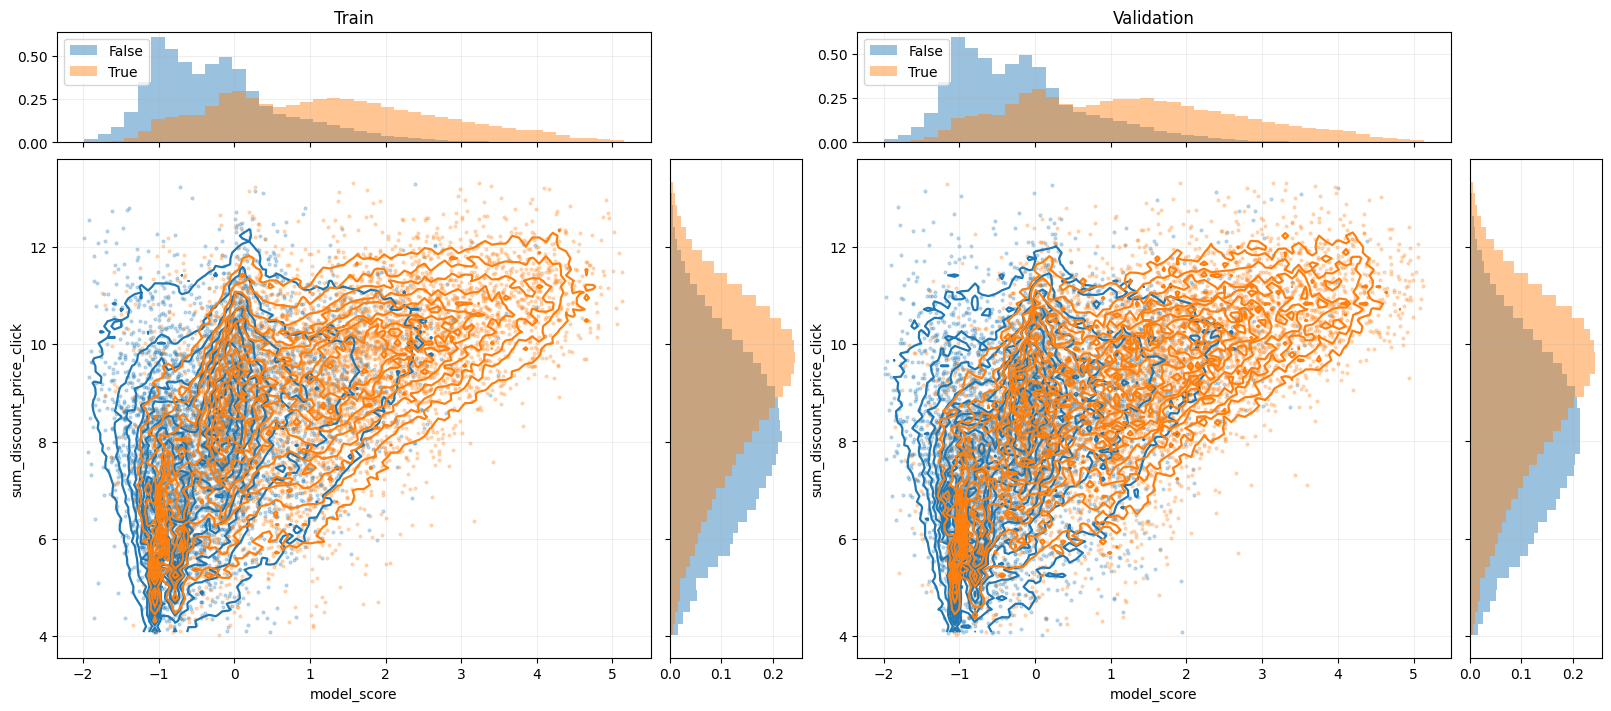

In [31]:
interpreter.plot_score_feature_contours(feature_name="sum_discount_price_click")

100%|===================| 4981/5000 [01:37<00:00]        

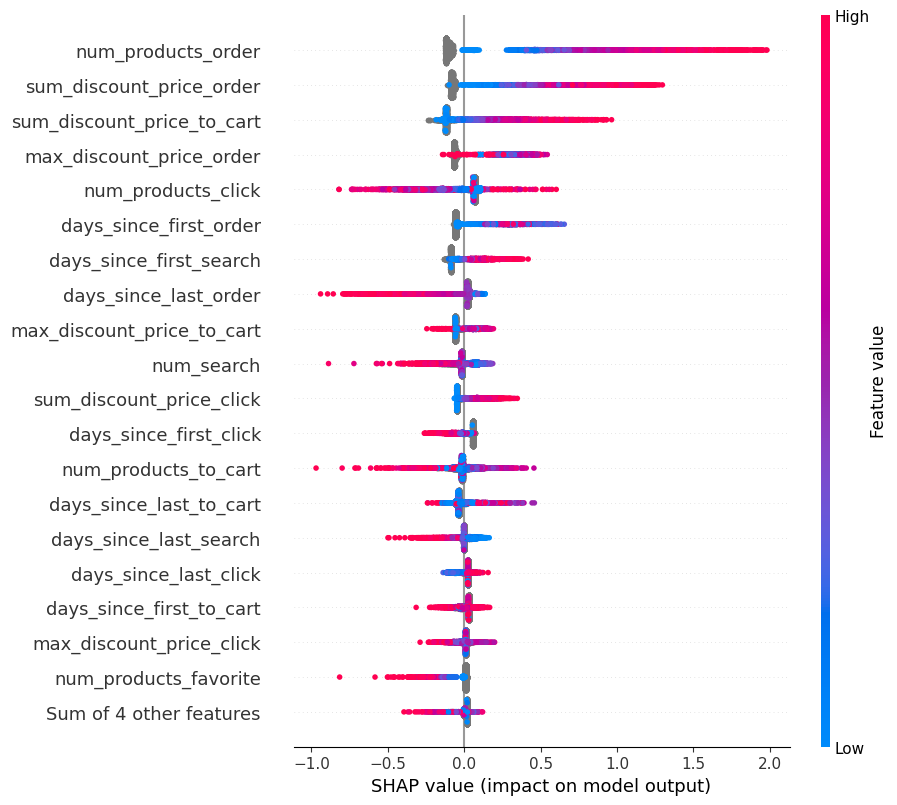

In [32]:
interpreter.plot_shap_beeswarm(max_display=20, sample_size=5000);

In [33]:
train_pool = catboost.Pool(
    X_train,
    label=y_train,
)
eval_pool = catboost.Pool(
    X_val,
    label=y_val,
)

In [34]:
train_pool.shape, eval_pool.shape

((1311636, 23), (563320, 23))

In [35]:
model.fit(
    train_pool, 
    eval_set=eval_pool,
    use_best_model=True,
    verbose=10,
    early_stopping_rounds=50,
)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7464139	best: 0.7464139 (0)	total: 10.8ms	remaining: 21.6s
10:	test: 0.7533818	best: 0.7533818 (10)	total: 109ms	remaining: 19.7s
20:	test: 0.7544571	best: 0.7544571 (20)	total: 211ms	remaining: 19.9s
30:	test: 0.7551281	best: 0.7551281 (30)	total: 301ms	remaining: 19.1s
40:	test: 0.7556111	best: 0.7556111 (40)	total: 391ms	remaining: 18.7s
50:	test: 0.7559006	best: 0.7559104 (49)	total: 482ms	remaining: 18.4s
60:	test: 0.7563458	best: 0.7563458 (60)	total: 576ms	remaining: 18.3s
70:	test: 0.7566409	best: 0.7566409 (70)	total: 667ms	remaining: 18.1s
80:	test: 0.7568346	best: 0.7568346 (80)	total: 760ms	remaining: 18s
90:	test: 0.7569607	best: 0.7569607 (90)	total: 854ms	remaining: 17.9s
100:	test: 0.7571425	best: 0.7571425 (100)	total: 948ms	remaining: 17.8s
110:	test: 0.7573377	best: 0.7573377 (110)	total: 1.04s	remaining: 17.7s
120:	test: 0.7574423	best: 0.7574423 (120)	total: 1.13s	remaining: 17.5s
130:	test: 0.7575461	best: 0.7575461 (130)	total: 1.22s	remaining: 17.4s
1

In [36]:
name = 'baseline1'
model.save_model(f"{name}.bin")

In [37]:
fi = model.get_feature_importance(eval_pool, prettified=True)
fi.head(50)

,Feature Id,Importances
0,sum_discount_price_order,19.910916
1,num_products_order,12.521977
2,days_since_last_order,10.317882
3,max_discount_price_order,9.895167
4,sum_discount_price_to_cart,6.597233
5,days_since_first_order,6.153890
6,num_products_to_cart,5.435511
7,days_since_last_to_cart,4.695910
8,num_search,4.294043
9,num_products_click,4.164587


In [38]:
test_users_submission = (
    pl.read_csv(os.path.join(data_path, 'test_users.csv'))
)

In [39]:
val_end_date, val_end_date - timedelta(days=30 * 4)

(datetime.date(2024, 7, 31), datetime.date(2024, 4, 2))

In [40]:
actions_aggs = {}
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    5: "to_cart",
}
for id_, suf in actions_id_to_suf.items():
    aggs = (
        actions_history
        .filter(pl.col('timestamp').dt.date() <= val_end_date)
        .filter(pl.col('timestamp').dt.date() >= val_end_date - timedelta(days=30 * 4))
        .filter(pl.col('action_type_id') == id_)
        .join(
            product_information
            .select('product_id', 'discount_price'),
            on='product_id',
        )
        .group_by('user_id')
        .agg(
            pl.count('product_id').cast(pl.Int32).alias(f'num_products_{suf}'),
            pl.sum('discount_price').cast(pl.Float32).alias(f'sum_discount_price_{suf}'),
            pl.max('discount_price').cast(pl.Float32).alias(f'max_discount_price_{suf}'),
            pl.max('timestamp').alias(f'last_{suf}_time'),
            pl.min('timestamp').alias(f'first_{suf}_time'),
        )
        .with_columns([
            (pl.lit(test_start_date) - pl.col(f'last_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_last_{suf}'),
            
            (pl.lit(test_start_date) - pl.col(f'first_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_first_{suf}'),
        ])
        .select(
            'user_id',
            f'num_products_{suf}',
            f'sum_discount_price_{suf}',
            f'max_discount_price_{suf}',
            f'days_since_last_{suf}',
            f'days_since_first_{suf}',
        )
    )
    actions_aggs[id_] = aggs

In [41]:
# search_aggs
id_ = 4
suf = 'search'
actions_aggs[id_] = (
    search_history
    .filter(pl.col('action_type_id') == id_)
    .filter(pl.col('timestamp').dt.date() <= val_end_date)
    .filter(pl.col('timestamp').dt.date() >= val_end_date - timedelta(days=30 * 4))
    .group_by('user_id')
    .agg(
        pl.count('search_query').cast(pl.Int32).alias(f'num_{suf}'),
        pl.max('timestamp').alias(f'last_{suf}_time'),
        pl.min('timestamp').alias(f'first_{suf}_time'),
    )
    .with_columns([
        (pl.lit(test_start_date) - pl.col(f'last_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_last_{suf}'),

        (pl.lit(test_start_date) - pl.col(f'first_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_first_{suf}'),
    ])
    .select(
        'user_id',
        f'num_{suf}',
        f'days_since_last_{suf}',
        f'days_since_first_{suf}',
    )
)

In [42]:
df = test_users_submission
for _, actions_aggs_df in actions_aggs.items():
    df = (
        df
        .join(actions_aggs_df, on='user_id', how='left')
    )

In [43]:
df_pd = df.to_pandas()

In [44]:
df_pd.shape

(2068424, 24)

In [45]:
df_pd['predict'] = model.predict(df_pd[cols], prediction_type="Probability")[:, 1]

In [46]:
df_pd[['user_id', 'predict']]

,user_id,predict
0,1342,0.354490
1,9852,0.807450
2,10206,0.351731
3,11317,0.347183
4,13289,0.427292
...,...,...
2068419,11157283,0.325582
2068420,11160395,0.227888
2068421,11165052,0.590995
2068422,11168218,0.687916


In [47]:
df_pd[['user_id', 'predict']].to_csv('baseline1_submission.csv', index=False)